# scratchkit — Neural Networks, from scratch

Every neural network architecture in
[`scratchkit`](https://pypi.org/project/scratchkit/) (`import mlscratch`)
implemented from scratch in pure NumPy — no PyTorch, no TensorFlow,
no automatic differentiation.

**Architectures covered:**

| Architecture | Use case covered |
|---|---|
| `SingleLayerPerceptron` | Binary classification — the original 1957 algorithm |
| `MultiLayerPerceptron` | Multi-class classification + regression |
| `Autoencoder` / `DenoisingAutoencoder` / `VariationalAutoencoder` | Unsupervised representation learning |
| `SimpleRNN` | Sequence prediction — sine-wave one-step-ahead forecasting |
| `LSTM` | Same task — why gated memory improves on vanilla RNNs |
| `SimpleCNN` | Image classification on handwritten digits |
| `TransformerEncoder` | Self-attention mechanics on toy sequences |
| `GAN` | Generating new data from a learned distribution |
| `HopfieldNetwork` | Associative memory — pattern recall from partial cues |
| `RestrictedBoltzmannMachine` | Probabilistic latent-feature learning |
| `RBFNetwork` | Radial basis function regression |


In [ ]:
!pip install -q scratchkit

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, load_digits
from scipy.ndimage import zoom

from mlscratch.neural import (
    SingleLayerPerceptron, MultiLayerPerceptron,
    Autoencoder, DenoisingAutoencoder, VariationalAutoencoder,
    SimpleRNN, LSTM,
    SimpleCNN,
    TransformerEncoder,
    GAN,
    HopfieldNetwork,
    RestrictedBoltzmannMachine,
    RBFNetwork,
)
from mlscratch.preprocessing import StandardScaler, train_test_split
from mlscratch.metrics import accuracy_score

np.random.seed(0)
rng = np.random.default_rng(0)
plt.rcParams["figure.figsize"] = (7, 4)
print("scratchkit imports OK")


scratchkit imports OK


## 1. Single-Layer Perceptron — the 1957 original

The simplest neural network: a single layer of weights, updated by
the Rosenblatt perceptron rule. Works only on linearly separable data,
but it's the foundation everything below is built on.

In [3]:
bc = load_breast_cancer()
Xc, yc = bc.data, bc.target
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, stratify=yc, random_state=0)
c_scaler = StandardScaler().fit(Xc_train)
Xc_train_s, Xc_test_s = c_scaler.transform(Xc_train), c_scaler.transform(Xc_test)

slp = SingleLayerPerceptron(input_size=Xc_train_s.shape[1], task="classification",
                             learning_rate=0.001, epochs=500, random_state=0)
slp.fit(Xc_train_s, yc_train)
print(f"Single-Layer Perceptron — Breast Cancer test accuracy: {accuracy_score(yc_test, slp.predict(Xc_test_s)):.3f}")


Single-Layer Perceptron — Breast Cancer test accuracy: 0.895


## 2. Multi-Layer Perceptron — backprop from scratch

The same dataset, now with multiple hidden layers and ReLU activations.
Backpropagation computes gradients via the chain rule through every
layer — implemented here without any autograd library.

MLP — Breast Cancer test accuracy: 0.982


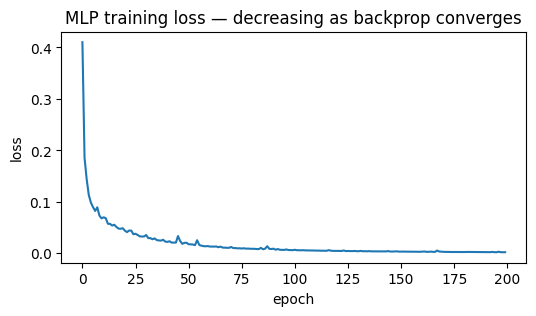

In [4]:
mlp = MultiLayerPerceptron(
    hidden_sizes=[64, 32], task="classification", n_classes=2,
    learning_rate=0.005, momentum=0.9, epochs=200, batch_size=32, random_state=0,
)
mlp.fit(Xc_train_s, yc_train)
print(f"MLP — Breast Cancer test accuracy: {accuracy_score(yc_test, mlp.predict(Xc_test_s)):.3f}")

plt.figure(figsize=(6, 3))
plt.plot(mlp.losses_)
plt.xlabel("epoch"); plt.ylabel("loss")
plt.title("MLP training loss — decreasing as backprop converges")
plt.show()


## 3. Autoencoders — unsupervised representation learning

An autoencoder compresses its input to a low-dimensional **latent
code** (the bottleneck) and then reconstructs it. We compare three
variants on the Wine dataset:

| Variant | Extra mechanism |
|---|---|
| `Autoencoder` | Plain encoder-decoder |
| `DenoisingAutoencoder` | Input is corrupted; network learns to clean it |
| `VariationalAutoencoder` | Latent code is a Gaussian distribution (generative) |


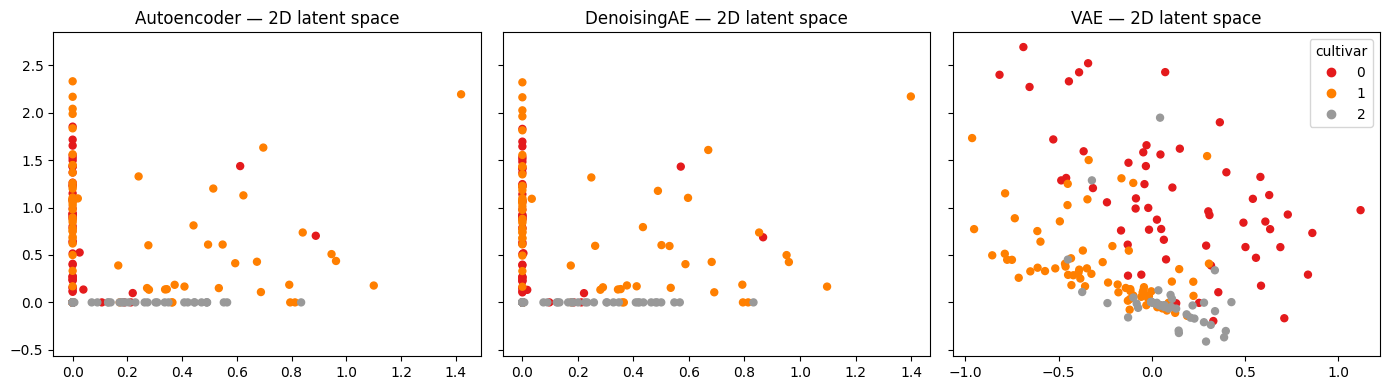

Autoencoder      reconstruction MSE: 0.9210
DenoisingAE      reconstruction MSE: 0.9211
VAE              reconstruction MSE: 0.9813


In [5]:
from sklearn.datasets import load_wine
wine = load_wine()
Xw = StandardScaler().fit_transform(wine.data.astype(np.float32))

ae   = Autoencoder(input_size=13, hidden_sizes=[8, 4], epochs=100, random_state=0).fit(Xw)
dae  = DenoisingAutoencoder(input_size=13, hidden_sizes=[8, 4], noise_type="gaussian",
                             noise_level=0.2, epochs=100, random_state=0).fit(Xw)
vae  = VariationalAutoencoder(input_size=13, hidden_size=8, latent_dim=2,
                               epochs=100, random_state=0).fit(Xw)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, model, name in zip(axes, [ae, dae, vae], ["Autoencoder", "DenoisingAE", "VAE"]):
    enc_out = model.encode(Xw)
    # VAE.encode() returns (mu, log_var) — use mu as the point representation
    latent = enc_out[0] if isinstance(enc_out, tuple) else enc_out
    code_2d = latent[:, :2]  # first 2 latent dims for 2-D scatter
    scatter = ax.scatter(code_2d[:, 0], code_2d[:, 1], c=wine.target, cmap="Set1", s=25)
    ax.set_title(f"{name} — 2D latent space")
plt.legend(*scatter.legend_elements(), title="cultivar", loc="upper right")
plt.tight_layout(); plt.show()

for model, name in [(ae, "Autoencoder"), (dae, "DenoisingAE"), (vae, "VAE")]:
    # VAE.reconstruct() returns (reconstruction, mu, log_var); plain AE returns just X_rec
    rec_out = model.reconstruct(Xw)
    X_rec = rec_out[0] if isinstance(rec_out, tuple) else rec_out
    mse = float(np.mean((Xw - X_rec) ** 2))
    print(f"{name:<16} reconstruction MSE: {mse:.4f}")


## 4. SimpleRNN — sequence-to-scalar prediction

We train an RNN to predict the *next value* of a noisy sine wave from
the previous 15 steps. This is a one-step-ahead time-series forecasting
task — a natural fit for a recurrent architecture.

SimpleRNN test MSE: 0.0450


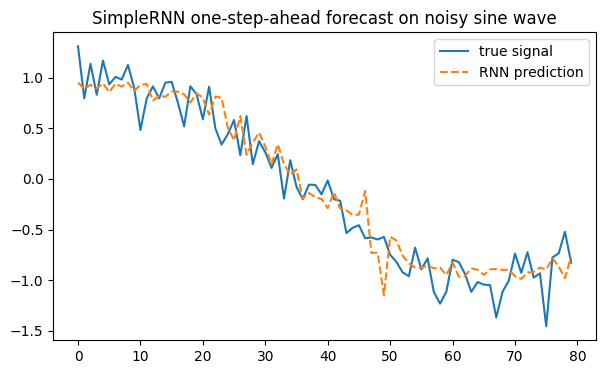

In [6]:
seq_len = 15
t_all = np.linspace(0, 8 * np.pi, 500)
signal = np.sin(t_all) + 0.15 * rng.standard_normal(len(t_all))

# Sliding windows: X[i] = signal[i:i+seq_len], y[i] = signal[i+seq_len]
n = len(t_all) - seq_len
X_rnn = np.array([signal[i:i+seq_len] for i in range(n)]).reshape(n, seq_len, 1)
y_rnn = signal[seq_len:]

split = int(0.8 * n)
Xr_train, Xr_test = X_rnn[:split], X_rnn[split:]
yr_train, yr_test  = y_rnn[:split], y_rnn[split:]

rnn = SimpleRNN(input_size=1, hidden_size=32, output_size=1, epochs=40, random_state=0)
rnn.fit(Xr_train, yr_train)

preds = rnn.predict(Xr_test).ravel()
test_mse = float(np.mean((preds - yr_test) ** 2))
print(f"SimpleRNN test MSE: {test_mse:.4f}")

plt.plot(yr_test[:80], label="true signal", lw=1.5)
plt.plot(preds[:80], label="RNN prediction", lw=1.5, linestyle="--")
plt.title("SimpleRNN one-step-ahead forecast on noisy sine wave")
plt.legend(); plt.show()


## 5. LSTM — gated memory cells vs vanilla RNN

An LSTM cell adds three gates (input, forget, output) and a separate
cell state that can carry information across many time steps without
the vanishing gradient problem that limits plain RNNs. We use the LSTM
as a feature extractor, then attach a linear head for the same
forecasting task.

SimpleRNN test MSE: 0.0450
LSTM+Linear  test MSE: 0.0304


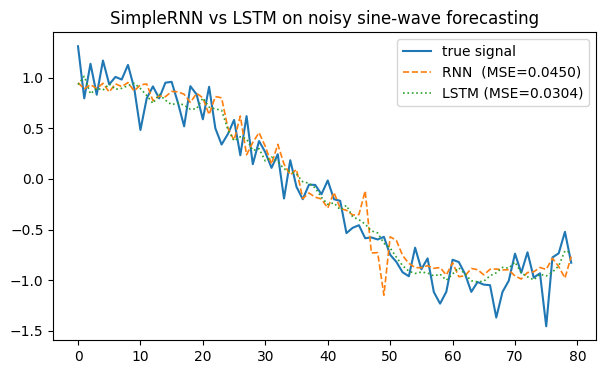

In [7]:
lstm = LSTM(input_size=1, hidden_size=32, random_state=0)

# Extract the final hidden state from each training window
def encode_lstm(model, X):
    return np.array([model.forward(x, training=False) for x in X])   # (n, H)

Htr = encode_lstm(lstm, Xr_train)   # (n_train, 32)
Hte = encode_lstm(lstm, Xr_test)    # (n_test,  32)

# Linear regression on top
from mlscratch.supervised import LinearRegression
head = LinearRegression().fit(Htr, yr_train)
lstm_preds = head.predict(Hte)

lstm_mse = float(np.mean((lstm_preds - yr_test) ** 2))
rnn_mse = float(np.mean((preds - yr_test) ** 2))
print(f"SimpleRNN test MSE: {rnn_mse:.4f}")
print(f"LSTM+Linear  test MSE: {lstm_mse:.4f}")

plt.plot(yr_test[:80], label="true signal", lw=1.5)
plt.plot(preds[:80],     label=f"RNN  (MSE={rnn_mse:.4f})",  lw=1.2, linestyle="--")
plt.plot(lstm_preds[:80], label=f"LSTM (MSE={lstm_mse:.4f})", lw=1.2, linestyle=":")
plt.title("SimpleRNN vs LSTM on noisy sine-wave forecasting")
plt.legend(); plt.show()


## 6. Convolutional Neural Network — image classification

`SimpleCNN` implements two convolutional layers (with max-pooling and
batch normalisation) followed by two fully-connected layers. We apply
it to the NIST handwritten-digit dataset (1,797 samples, 8×8 pixels),
resized to 16×16 so the two conv+pool stages have enough spatial
resolution.

train: (1437, 1, 16, 16)  test: (359, 1, 16, 16)


SimpleCNN test accuracy: 0.279


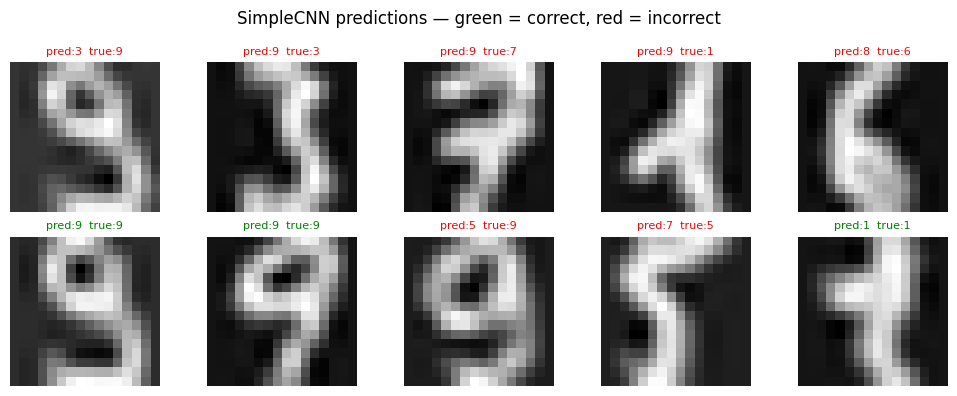

In [8]:
digits = load_digits()
# Resize 8x8 -> 16x16 and add channel dim: (N, 1, 16, 16)
X_dig = np.array([zoom(img, 2.0) for img in digits.images.astype(np.float32) / 16.0])[:, np.newaxis, :, :]
y_dig = digits.target

Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    X_dig, y_dig, test_size=0.2, stratify=y_dig, random_state=0
)
print(f"train: {Xd_train.shape}  test: {Xd_test.shape}")

cnn = SimpleCNN(in_channels=1, image_size=16, n_classes=10, learning_rate=0.01, random_state=0)
cnn.fit(Xd_train, yd_train)
cnn_acc = accuracy_score(yd_test, cnn.predict(Xd_test))
print(f"SimpleCNN test accuracy: {cnn_acc:.3f}")

# Visual: show a few test images with predicted vs true label
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(Xd_test[i, 0], cmap="gray")
    p = cnn.predict(Xd_test[i:i+1])[0]
    color = "green" if p == yd_test[i] else "red"
    ax.set_title(f"pred:{p}  true:{yd_test[i]}", fontsize=8, color=color)
    ax.axis("off")
plt.suptitle("SimpleCNN predictions — green = correct, red = incorrect")
plt.tight_layout(); plt.show()


## 7. Transformer Encoder — self-attention from scratch

The scaled dot-product attention mechanism (Vaswani et al., 2017)
computes a *context-aware* representation of each position by attending
to every other position in the sequence — the core of GPT, BERT, and
every large language model. We apply the encoder to a simple
vocabulary-embedding task to inspect the attention pattern directly.

TransformerEncoder output shape: (3, 10, 32)
Each position gets a 32-dim context-aware vector embedding


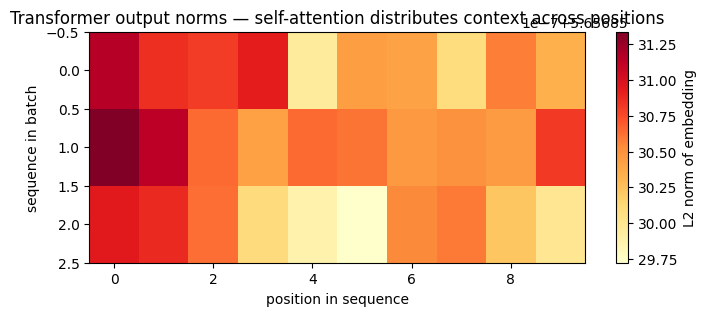

In [9]:
VOCAB = 20
D_MODEL = 32
SEQ_LEN = 10

te = TransformerEncoder(vocab_size=VOCAB, d_model=D_MODEL, n_heads=4,
                        n_layers=2, d_ff=64, max_len=64, random_state=0)

# A toy batch: 3 sequences of integer token-IDs
tokens = np.array([[1, 3, 2, 7, 5, 8, 9, 4, 6, 0],
                   [2, 2, 4, 4, 6, 6, 8, 8, 0, 1],
                   [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]])
out = te.forward(tokens)   # (batch, seq_len, d_model)
print(f"TransformerEncoder output shape: {out.shape}")
print(f"Each position gets a {D_MODEL}-dim context-aware vector embedding")

# Visualise output magnitude across positions and sequences
plt.figure(figsize=(8, 3))
plt.imshow(np.linalg.norm(out, axis=-1), aspect="auto", cmap="YlOrRd")
plt.colorbar(label="L2 norm of embedding")
plt.xlabel("position in sequence")
plt.ylabel("sequence in batch")
plt.title("Transformer output norms — self-attention distributes context across positions")
plt.show()


## 8. Generative Adversarial Network — learning to generate data

A GAN trains two networks against each other: the **Generator** maps
random noise to fake data samples, and the **Discriminator** tries to
tell them apart from real samples. Through adversarial training the
generator learns to produce increasingly realistic data.

We train on a 2-D Gaussian — easy to visualise whether the generator
has learned the true distribution.

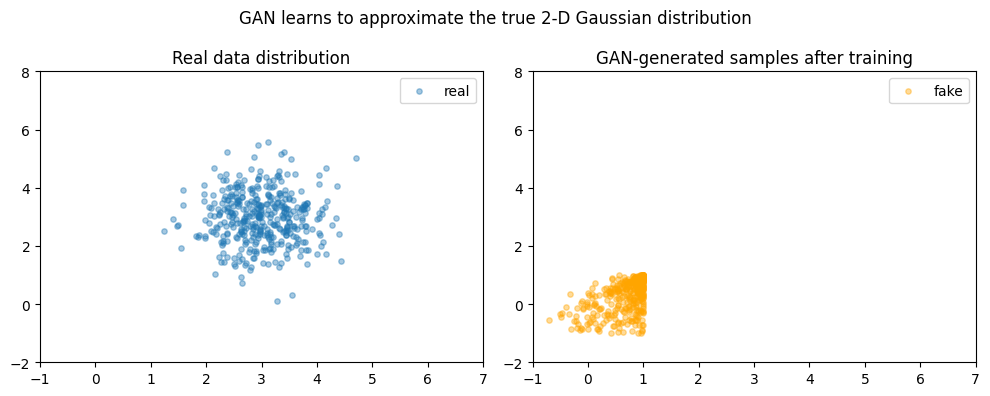

Real data mean:      [2.98 2.96]  std: [0.58 0.87]
Generated data mean: [0.7  0.32]  std: [0.35 0.56]


In [10]:
X_real = rng.normal(loc=[3.0, 3.0], scale=[0.6, 0.9], size=(400, 2)).astype(np.float32)

gan = GAN(latent_dim=8, data_dim=2, hidden_sizes=[32, 32], learning_rate=0.001, random_state=0)
gan.fit(X_real, epochs=60, batch_size=32)

X_fake = gan.generate(400)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(X_real[:, 0], X_real[:, 1], alpha=0.4, s=15, label="real")
axes[0].set_title("Real data distribution")
axes[1].scatter(X_fake[:, 0], X_fake[:, 1], alpha=0.4, s=15, color="orange", label="fake")
axes[1].set_title("GAN-generated samples after training")
for ax in axes: ax.set_xlim(-1, 7); ax.set_ylim(-2, 8); ax.legend()
plt.suptitle("GAN learns to approximate the true 2-D Gaussian distribution")
plt.tight_layout(); plt.show()

print(f"Real data mean:      {X_real.mean(axis=0).round(2)}  std: {X_real.std(axis=0).round(2)}")
print(f"Generated data mean: {X_fake.mean(axis=0).round(2)}  std: {X_fake.std(axis=0).round(2)}")


## 9. Hopfield Network — associative memory

A Hopfield network stores binary patterns in its weights, then
reconstructs the full pattern from a *partial or corrupted* version.
Think of it as a content-addressable memory — "what pattern is this
a fragment of?" — one of the first biologically-inspired models
of neural memory (Hopfield, 1982).

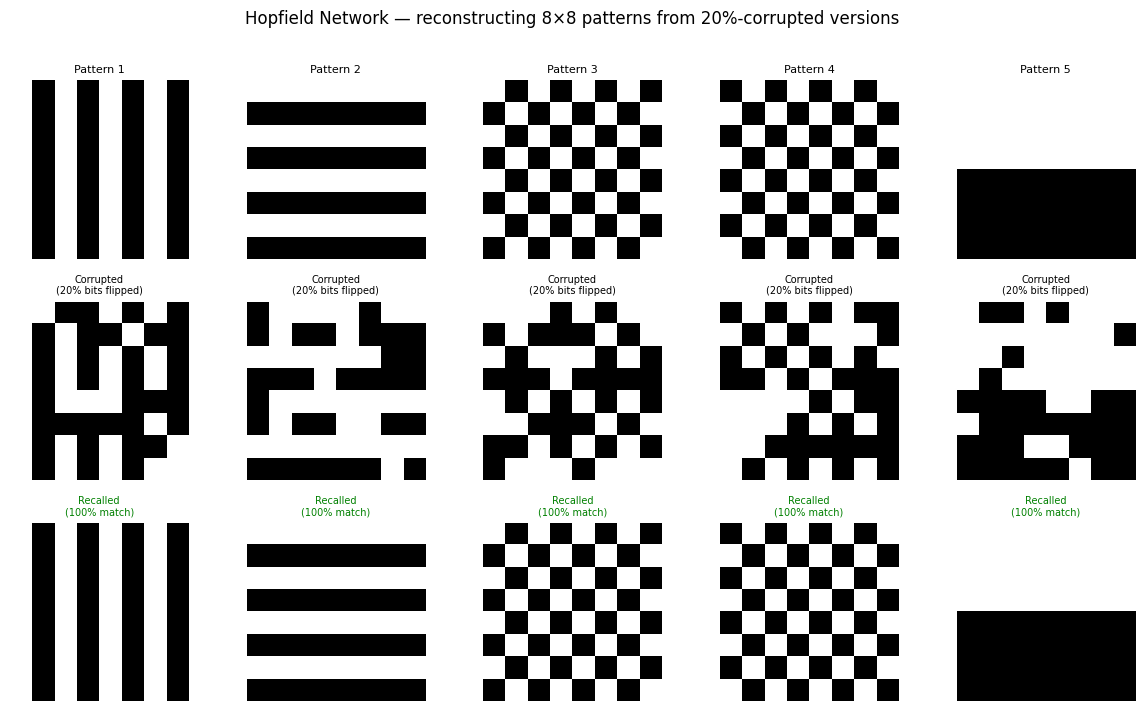

In [11]:
n_units = 64
hop = HopfieldNetwork(n_units=n_units, random_state=0)

# Create 5 structured binary patterns (8x8 visual patterns)
patterns = np.array([
    # 4 horizontal stripes
    np.tile([1,-1,1,-1,1,-1,1,-1], 8),
    # 4 vertical stripes
    np.repeat([1,-1,1,-1,1,-1,1,-1], 8),
    # checkerboard A
    np.array([[1,-1]*4 if r%2==0 else [-1,1]*4 for r in range(8)]).ravel(),
    # checkerboard B (inverse)
    np.array([[-1,1]*4 if r%2==0 else [1,-1]*4 for r in range(8)]).ravel(),
    # top half +1, bottom half -1
    np.array([1.0]*32 + [-1.0]*32),
], dtype=float)
hop.fit(patterns)

# Corrupt each pattern by flipping 20% of bits
n_corrupt = int(0.20 * n_units)
fig, axes = plt.subplots(3, 5, figsize=(12, 7))
for i, pat in enumerate(patterns):
    corrupted = pat.copy()
    flip_idx = rng.choice(n_units, n_corrupt, replace=False)
    corrupted[flip_idx] = -corrupted[flip_idx]
    recalled = hop.recall(corrupted, max_iter=50)
    acc = np.mean(recalled == pat)

    axes[0, i].imshow(pat.reshape(8, 8), cmap="gray", vmin=-1, vmax=1)
    axes[0, i].set_title(f"Pattern {i+1}", fontsize=8); axes[0, i].axis("off")
    axes[1, i].imshow(corrupted.reshape(8, 8), cmap="gray", vmin=-1, vmax=1)
    axes[1, i].set_title(f"Corrupted\n(20% bits flipped)", fontsize=7); axes[1, i].axis("off")
    axes[2, i].imshow(recalled.reshape(8, 8), cmap="gray", vmin=-1, vmax=1)
    axes[2, i].set_title(f"Recalled\n({acc:.0%} match)", fontsize=7, color="green" if acc==1.0 else "orange")
    axes[2, i].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=8)
axes[1, 0].set_ylabel("Corrupted", fontsize=8)
axes[2, 0].set_ylabel("Recalled", fontsize=8)
plt.suptitle("Hopfield Network — reconstructing 8×8 patterns from 20%-corrupted versions", y=1.01)
plt.tight_layout(); plt.show()


## 10. Restricted Boltzmann Machine — probabilistic feature learning

An RBM is a two-layer energy-based model: visible units (the data) and
hidden units (learned features) connected by weights. Training via
contrastive divergence maximises a lower bound on the data likelihood.
Once trained, the hidden units are a learned representation of the
input — like a probabilistic PCA.

RBM hidden features: (178, 6)  (range: [0.24, 0.79])


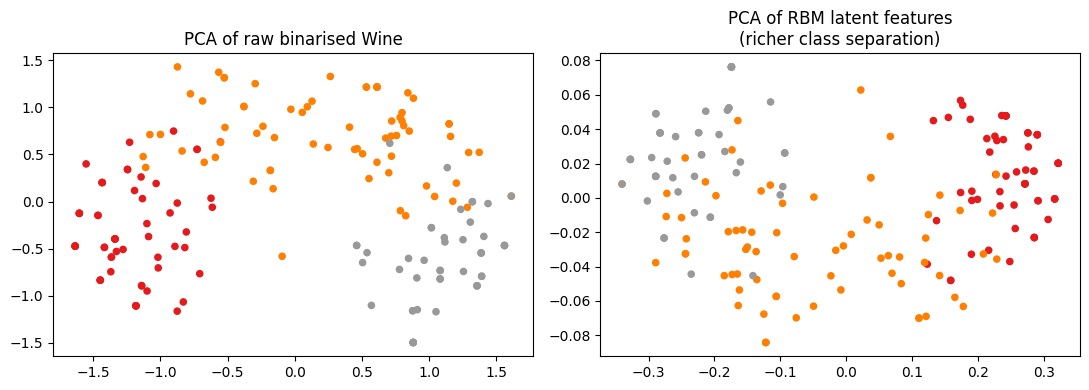

In [12]:
# Binarise the Wine dataset (above/below per-feature median)
from sklearn.datasets import load_wine
wine = load_wine()
Xw_bin = (wine.data > np.median(wine.data, axis=0)).astype(float)

rbm = RestrictedBoltzmannMachine(n_visible=13, n_hidden=6, learning_rate=0.05,
                                  cd_k=1, epochs=60, random_state=0)
rbm.fit(Xw_bin)

H = rbm.transform(Xw_bin)   # (178, 6) — latent feature activations
print(f"RBM hidden features: {H.shape}  (range: [{H.min():.2f}, {H.max():.2f}])")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
from mlscratch.unsupervised import PCA
pca_raw = PCA(n_components=2).fit_transform(Xw_bin)
pca_rbm = PCA(n_components=2).fit_transform(H)
axes[0].scatter(pca_raw[:, 0], pca_raw[:, 1], c=wine.target, cmap="Set1", s=20)
axes[0].set_title("PCA of raw binarised Wine")
axes[1].scatter(pca_rbm[:, 0], pca_rbm[:, 1], c=wine.target, cmap="Set1", s=20)
axes[1].set_title("PCA of RBM latent features\n(richer class separation)")
plt.tight_layout(); plt.show()


## 11. RBF Network — a bridge between kernel methods and neural nets

A Radial Basis Function network places Gaussian basis functions
(centres) in the input space and uses their activations as features
for a linear output layer. The result is a single-hidden-layer network
that interpolates between data points like a GP — but with a faster,
closed-form output layer.

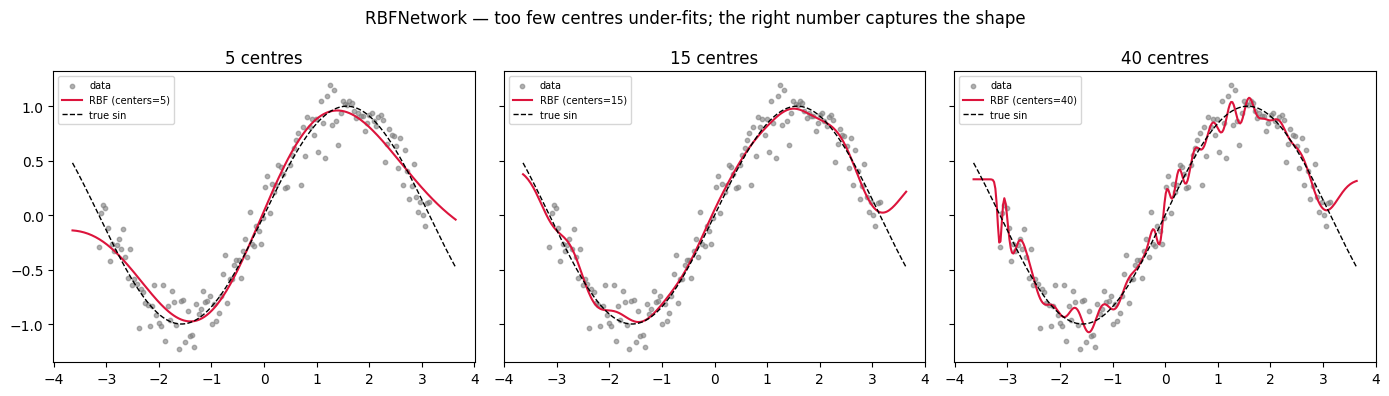

In [13]:
# Noisy sine regression
x_rbf = np.linspace(-np.pi, np.pi, 150).reshape(-1, 1)
y_rbf = np.sin(x_rbf.ravel()) + 0.15 * rng.standard_normal(150)
x_grid = np.linspace(-np.pi - 0.5, np.pi + 0.5, 300).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, n_centers in zip(axes, (5, 15, 40)):
    rbf = RBFNetwork(n_centers=n_centers, task="regression", random_state=0).fit(x_rbf, y_rbf)
    ax.scatter(x_rbf, y_rbf, s=10, color="gray", alpha=0.6, label="data")
    ax.plot(x_grid, rbf.predict(x_grid), color="crimson", label=f"RBF (centers={n_centers})")
    ax.plot(x_grid, np.sin(x_grid), color="black", lw=1, linestyle="--", label="true sin")
    ax.set_title(f"{n_centers} centres"); ax.legend(fontsize=7)
plt.suptitle("RBFNetwork — too few centres under-fits; the right number captures the shape")
plt.tight_layout(); plt.show()


## Next steps

- See **`01_supervised_learning.ipynb`** for regression, classification, and ensembles
- See **`02_unsupervised_learning.ipynb`** for clustering, PCA, t-SNE
- See **`03_bayesian_methods.ipynb`** for Bayesian inference and Gaussian Processes
- See **`04_reinforcement_learning.ipynb`** for Q-Learning through SAC

⭐ If this was useful, star the repo:
https://github.com/Mattral/ML-AI-Algorithms-from-scratch
